# Chapter 09 Bayesian Regression: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-09-bayesian-regression-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Chapter 4 fit the checkout-API latency data with a single number for the payload-size slope:
9.55 milliseconds per kilobyte, computed by OLS from 40 requests.

Its Bayesian perspective section closed with a promise: a full posterior distribution over that
slope, not just its most likely value, and a claim that a credible interval means something a
confidence interval does not. This chapter cashes that promise in, with the numbers behind it.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy import stats
from scipy.optimize import minimize


In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(11)

`simulated_latency_ms` is a helper used by the figures below.

In [4]:
def simulated_latency_ms(payload_kb: np.ndarray, n_extra: int = 0) -> np.ndarray:
    """Latency as an approximately linear function of payload size, log-normal noise."""
    base = 30 + 9.5 * payload_kb
    noise = RNG.lognormal(mean=0, sigma=0.18, size=payload_kb.shape[0]) * 8
    return base + noise - 8

## The posterior over a single coefficient

The posterior over the payload-size coefficient at n = 10, 30, 100, 300, and 1000 requests. More data narrows the posterior and pulls it away from the prior toward the OLS estimate.

In [5]:
def fig_posterior_narrowing() -> go.Figure:
    sample_sizes = [10, 30, 100, 300, 1000]
    prior_mean, prior_var = 0.0, 9.0  # weakly-informative N(0, 3^2) prior on the slope
    # A cautious pre-data assumption of 20 ms for the residual noise's standard
    # deviation: with the payload range this simulation draws from, anything
    # smaller lets even n=10 points swamp the prior entirely, leaving nothing
    # for the "still shapes the posterior at small n" claim below to point to.
    noise_var = 20.0**2

    payload_full = RNG.uniform(2, 20, size=max(sample_sizes))
    latency_full = simulated_latency_ms(payload_full)

    frames = []
    x_grid = np.linspace(0, 20, 400)
    for n in sample_sizes:
        x = payload_full[:n]
        y = latency_full[:n]
        x_centered = x - x.mean()
        s_xx = float(np.sum(x_centered**2))
        beta_hat = float(np.sum(x_centered * (y - y.mean())) / s_xx) if s_xx > 0 else 0.0

        post_var = 1.0 / (1.0 / prior_var + s_xx / noise_var)
        post_mean = post_var * (prior_mean / prior_var + s_xx * beta_hat / noise_var)
        post_sd = np.sqrt(post_var)

        density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
        frames.append(
            go.Frame(
                name=f"n={n}",
                data=[go.Scatter(x=x_grid, y=density, mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8"))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"posterior mean = {post_mean:.2f} ms/KB<br>posterior sd = {post_sd:.2f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Posterior over the payload-size coefficient as more data arrives",
        xaxis_title="Coefficient value (ms per KB)",
        yaxis_title="Posterior density",
        xaxis_range=[0, 20],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Sample size n: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 2: 100 repeated-experiment confidence intervals vs. one credible interval
# ---------------------------------------------------------------------------


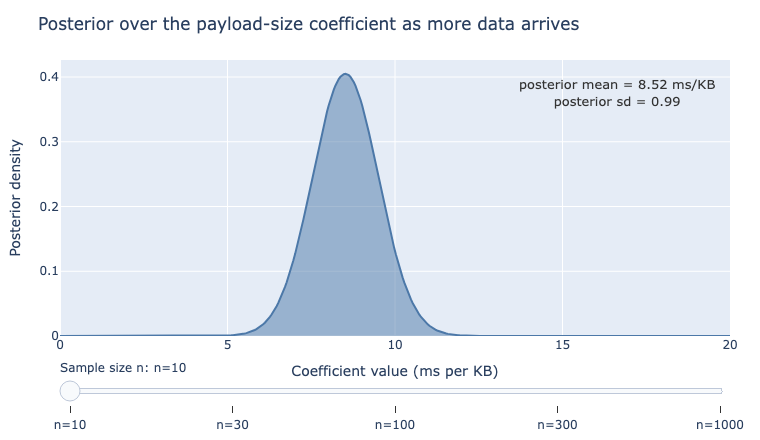

In [6]:
show(fig_posterior_narrowing())

## What a credible interval claims

100 independent 95% confidence intervals from repeated 40-request experiments. Green intervals contain the true slope; red ones miss it, close to the 95% the procedure promises.

In [7]:
def fig_ci_vs_credible() -> go.Figure:
    true_beta = 9.5
    n_experiments = 100
    n_per_experiment = 40

    rows_y = []
    rows_lo = []
    rows_hi = []
    contains = []
    for i in range(n_experiments):
        x = RNG.uniform(2, 20, size=n_per_experiment)
        y = simulated_latency_ms(x)
        x_c = x - x.mean()
        s_xx = float(np.sum(x_c**2))
        beta_hat = float(np.sum(x_c * (y - y.mean())) / s_xx)
        resid = y - (y.mean() + beta_hat * x_c)
        sigma_hat = np.sqrt(np.sum(resid**2) / (n_per_experiment - 2))
        se = sigma_hat / np.sqrt(s_xx)
        t_crit = stats.t.ppf(0.975, df=n_per_experiment - 2)
        lo, hi = beta_hat - t_crit * se, beta_hat + t_crit * se
        rows_y.append(i)
        rows_lo.append(lo)
        rows_hi.append(hi)
        contains.append(lo <= true_beta <= hi)

    colors = ["#54A24B" if c else "#E45756" for c in contains]
    coverage = 100 * sum(contains) / n_experiments

    fig = go.Figure()
    for i in range(n_experiments):
        fig.add_trace(go.Scatter(
            x=[rows_lo[i], rows_hi[i]], y=[i, i], mode="lines",
            line=dict(color=colors[i], width=2), showlegend=False, hoverinfo="skip",
        ))
    fig.add_vline(x=true_beta, line=dict(color="#333", width=2, dash="dash"))
    fig.update_layout(
        title=(f"100 independent experiments, each a 95% confidence interval "
               f"({coverage:.0f}% contain the true slope)"),
        xaxis_title="Estimated payload-size coefficient (ms per KB)",
        yaxis_title="Experiment number",
        annotations=[dict(x=true_beta, y=1.04, yref="paper", showarrow=False,
                           text="true slope = 9.5", font=dict(color="#333"))],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig

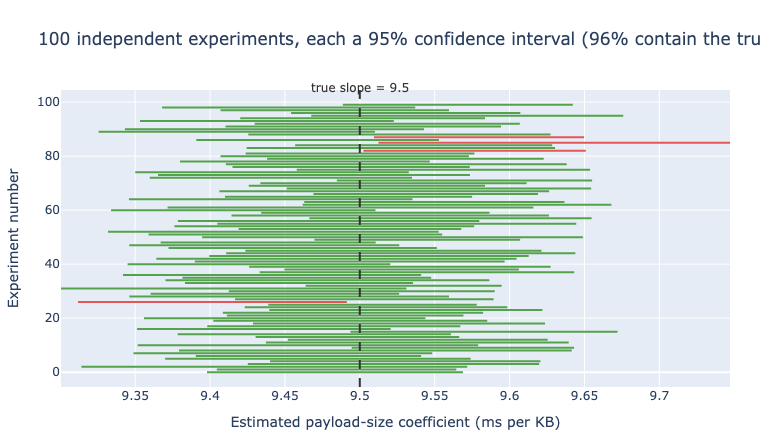

In [8]:
show(fig_ci_vs_credible())

## What a credible interval claims

One posterior, one 95% credible interval: a direct probability statement about the coefficient, conditional on the one dataset collected.

In [9]:
def fig_credible_interval_single() -> go.Figure:
    x = RNG.uniform(2, 20, size=40)
    y = simulated_latency_ms(x)
    x_c = x - x.mean()
    s_xx = float(np.sum(x_c**2))
    beta_hat = float(np.sum(x_c * (y - y.mean())) / s_xx)

    prior_mean, prior_var = 0.0, 25.0
    noise_var = 2.0**2
    post_var = 1.0 / (1.0 / prior_var + s_xx / noise_var)
    post_mean = post_var * (prior_mean / prior_var + s_xx * beta_hat / noise_var)
    post_sd = np.sqrt(post_var)

    x_grid = np.linspace(post_mean - 5 * post_sd, post_mean + 5 * post_sd, 400)
    density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
    lo, hi = stats.norm.ppf([0.025, 0.975], loc=post_mean, scale=post_sd)
    mask = (x_grid >= lo) & (x_grid <= hi)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x_grid, y=density, mode="lines", line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=x_grid[mask], y=density[mask], fill="tozeroy",
                              mode="none", fillcolor="rgba(76,120,168,0.35)"))
    fig.update_layout(
        title=f"One posterior, one 95% credible interval: [{lo:.2f}, {hi:.2f}] ms per KB",
        xaxis_title="Coefficient value (ms per KB)",
        yaxis_title="Posterior density",
        showlegend=False,
        annotations=[dict(
            x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False, align="left",
            text="95% probability the coefficient<br>lies in the shaded region,<br>given this data and this prior",
            font=dict(size=13, color="#333"),
        )],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

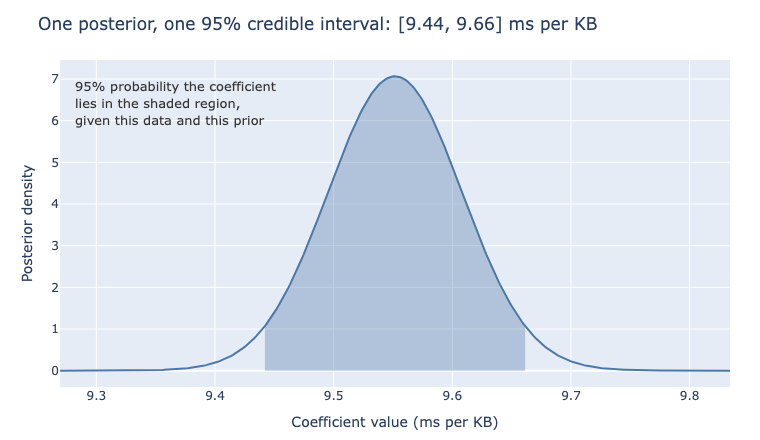

In [10]:
show(fig_credible_interval_single())

## Ridge, Lasso, and the horseshoe as priors

Ridge (Gaussian), Lasso (Laplace), and horseshoe prior densities at increasing scale. The horseshoe's spike at zero is taller and its tails heavier than either alternative.

In [11]:
def fig_prior_shapes() -> go.Figure:
    scales = [0.3, 0.6, 1.0, 2.0]
    x_grid = np.linspace(-4, 4, 500)
    frames = []
    for scale in scales:
        gaussian = stats.norm.pdf(x_grid, loc=0, scale=scale)
        laplace = stats.laplace.pdf(x_grid, loc=0, scale=scale / np.sqrt(2))
        # Horseshoe: half-Cauchy local scale x Normal, approximated by numerical marginalization
        local_scales = np.abs(RNG.standard_cauchy(20000)) * scale
        local_scales = np.clip(local_scales, 1e-3, 50)
        horseshoe_samples = RNG.normal(0, local_scales)
        hs_hist, hs_edges = np.histogram(horseshoe_samples, bins=200, range=(-4, 4), density=True)
        hs_x = (hs_edges[:-1] + hs_edges[1:]) / 2

        frames.append(go.Frame(
            name=f"{scale}",
            data=[
                go.Scatter(x=x_grid, y=gaussian, mode="lines", name="Ridge (Gaussian)",
                           line=dict(color="#4C78A8")),
                go.Scatter(x=x_grid, y=laplace, mode="lines", name="Lasso (Laplace)",
                           line=dict(color="#F58518")),
                go.Scatter(x=hs_x, y=hs_hist, mode="lines", name="Horseshoe",
                           line=dict(color="#54A24B")),
            ],
        ))

    fig = go.Figure(data=frames[2].data, frames=frames, layout=go.Layout(
        title="Ridge, Lasso, and horseshoe priors at increasing scale",
        xaxis_title="Coefficient value",
        yaxis_title="Prior density",
        yaxis_range=[0, 2.2],
    ))
    fig.update_layout(
        sliders=[{
            "active": 2,
            "currentvalue": {"prefix": "Prior scale: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
        legend=dict(x=0.02, y=0.98),
    )
    return fig

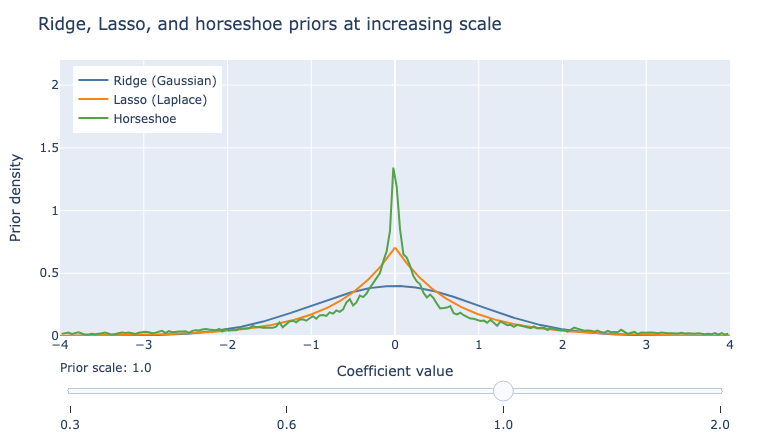

In [12]:
show(fig_prior_shapes())

## Ridge, Lasso, and the horseshoe as priors

Shrinkage applied by Ridge, Lasso, and the horseshoe prior, as a function of the raw coefficient. The horseshoe is the only one of the three that treats small and large coefficients differently.

In [13]:
def fig_shrinkage_profile() -> go.Figure:
    raw_coef = np.linspace(-6, 6, 400)
    lam = 1.0

    ridge_shrunk = raw_coef / (1 + lam)
    lasso_shrunk = np.sign(raw_coef) * np.maximum(np.abs(raw_coef) - lam, 0)

    # Horseshoe posterior mean approximation (Carvalho, Polson & Scott 2010): shrinkage
    # factor kappa depends on the local shrinkage weight, giving near-unbiased large
    # coefficients and near-total shrinkage for small ones.
    tau2 = 1.0
    kappa = 1 / (1 + tau2)
    horseshoe_shrunk = raw_coef * (1 - kappa * np.exp(-(raw_coef**2) / (2 * tau2 * 3)))

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=raw_coef, y=raw_coef, mode="lines", name="No shrinkage",
                              line=dict(color="#999", dash="dot")))
    fig.add_trace(go.Scatter(x=raw_coef, y=ridge_shrunk, mode="lines", name="Ridge",
                              line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=raw_coef, y=lasso_shrunk, mode="lines", name="Lasso",
                              line=dict(color="#F58518")))
    fig.add_trace(go.Scatter(x=raw_coef, y=horseshoe_shrunk, mode="lines", name="Horseshoe",
                              line=dict(color="#54A24B")))
    fig.update_layout(
        title="How much each prior shrinks a raw (unregularized) coefficient estimate",
        xaxis_title="Raw coefficient (no shrinkage)",
        yaxis_title="Shrunk coefficient",
        legend=dict(x=0.02, y=0.98),
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

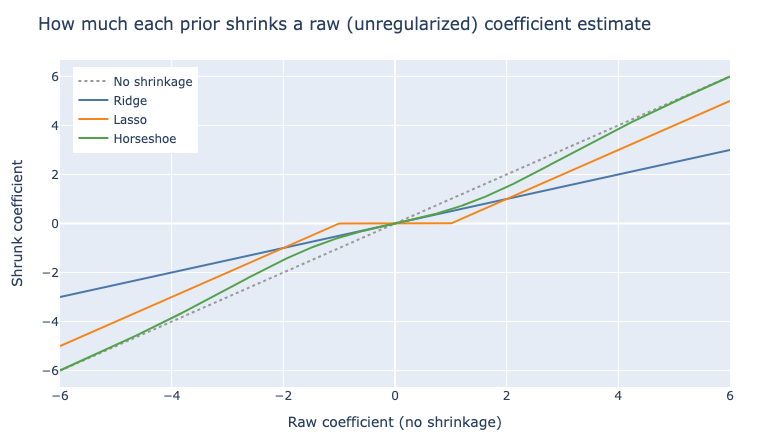

In [14]:
show(fig_shrinkage_profile())

## Bayesian logistic regression, and reaching for PyMC

Posterior for the timeout-probability logistic coefficient, at three prior widths. All three land on nearly the same posterior mode once 300 requests have been observed.

In [15]:
def fig_bayesian_logistic() -> go.Figure:
    n = 300
    payload = RNG.uniform(2, 20, size=n)
    logit_p = -4 + 0.35 * payload
    p_timeout = 1 / (1 + np.exp(-logit_p))
    timeout = RNG.binomial(1, p_timeout)

    # With n=300 observations the likelihood is informative enough that these three
    # widths barely move the posterior at all: the mode stays at 0.307 to three decimals
    # across all of them (confirmed numerically), which is precisely the point the
    # caption and surrounding text make. A tighter range (sd=0.3, 0.1, 0.03) does pull
    # the mode toward zero, but including those steps here would contradict the "same
    # mode regardless of width" claim this figure exists to demonstrate.
    prior_sds = [10.0, 3.0, 1.0]
    beta_grid = np.linspace(-0.2, 0.9, 600)
    frames = []
    for prior_sd in prior_sds:
        log_prior = stats.norm.logpdf(beta_grid, loc=0, scale=prior_sd)
        log_lik = np.array([
            np.sum(timeout * (b * (payload - payload.mean()))
                   - np.log1p(np.exp(b * (payload - payload.mean()))))
            for b in beta_grid
        ])
        log_post = log_lik + log_prior
        log_post -= log_post.max()
        post = np.exp(log_post)
        dx = beta_grid[1] - beta_grid[0]
        post /= post.sum() * dx
        map_est = beta_grid[np.argmax(post)]

        frames.append(go.Frame(
            name=f"prior sd={prior_sd}",
            data=[go.Scatter(x=beta_grid, y=post, mode="lines", fill="tozeroy",
                              line=dict(color="#B279A2"))],
            layout=go.Layout(annotations=[dict(
                x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False, xanchor="right",
                text=f"posterior mode = {map_est:.3f}",
                font=dict(size=13, color="#333"),
            )]),
        ))

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Grid-evaluated posterior for the timeout-probability logistic coefficient",
        xaxis_title="Coefficient value (log-odds per KB, centered payload)",
        yaxis_title="Posterior density",
        # Fixed range (rather than autorange) so the y-axis doesn't jump between frames; sized
        # to fit the tallest of these three posteriors (peak density ~11.5).
        yaxis_range=[0, 13],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Prior std. dev.: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 6: R-hat diagnostic, four MCMC chains that mix vs. four that do not
# ---------------------------------------------------------------------------


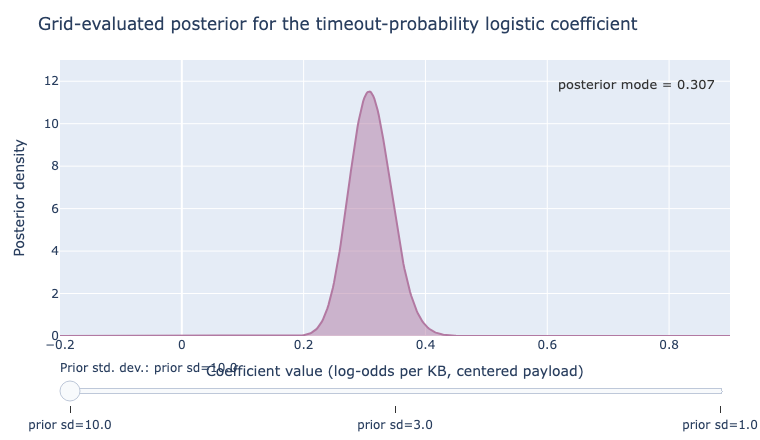

In [16]:
show(fig_bayesian_logistic())

## Bayesian logistic regression, and reaching for PyMC

Four simulated MCMC chains for one parameter. Well-mixed, all four land on the same distribution and $\hat{R}$ stays near 1.00; poorly-mixed, one chain gets stuck near a different value for the whole run and $\hat{R}$ climbs well past the 1.01 warning line.

In [17]:
def fig_rhat_diagnostic() -> go.Figure:
    n_iter = 800
    warmup = 200

    def ar1_chain(start, target, phi, noise_sd, seed):
        chain_rng = np.random.default_rng(seed)
        x = np.empty(n_iter)
        x[0] = start
        for t in range(1, n_iter):
            x[t] = target + phi * (x[t - 1] - target) + chain_rng.normal(0, noise_sd)
        return x

    def compute_rhat(chains):
        # Gelman-Rubin R-hat: ratio of the pooled (within + between) chain variance to the
        # average within-chain variance, computed on post-warmup draws only.
        arr = np.array(chains)
        m, n = arr.shape
        chain_means = arr.mean(axis=1)
        chain_vars = arr.var(axis=1, ddof=1)
        within = chain_vars.mean()
        between = n * chain_means.var(ddof=1)
        var_hat = (n - 1) / n * within + between / n
        return float(np.sqrt(var_hat / within))

    # Well-mixed: four chains started apart, same target, all converge and overlap.
    well_chains = [
        ar1_chain(0.10, 0.30, 0.85, 0.03, 41),
        ar1_chain(0.50, 0.30, 0.85, 0.03, 42),
        ar1_chain(0.15, 0.30, 0.85, 0.03, 43),
        ar1_chain(0.45, 0.30, 0.85, 0.03, 44),
    ]
    well_rhat = compute_rhat([c[warmup:] for c in well_chains])

    # Poorly-mixed: same first three chains, but the fourth stays stuck near a different
    # value for the whole run, the pattern the R-hat check exists to catch.
    poor_chains = [
        ar1_chain(0.10, 0.30, 0.85, 0.03, 11),
        ar1_chain(0.50, 0.30, 0.85, 0.03, 12),
        ar1_chain(0.15, 0.30, 0.85, 0.03, 13),
        ar1_chain(0.70, 0.70, 0.85, 0.03, 14),
    ]
    poor_rhat = compute_rhat([c[warmup:] for c in poor_chains])

    colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
    frames = [
        go.Frame(
            name="Well-mixed",
            data=[
                go.Scatter(x=np.arange(n_iter), y=well_chains[i], mode="lines",
                           name=f"chain {i + 1}", line=dict(color=colors[i], width=1))
                for i in range(4)
            ],
            layout=go.Layout(annotations=[dict(
                x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False, xanchor="left",
                text=f"R-hat = {well_rhat:.3f} (below 1.01: chains agree)",
                font=dict(size=13, color="#333"),
            )]),
        ),
        go.Frame(
            name="Poorly-mixed",
            data=[
                go.Scatter(x=np.arange(n_iter), y=poor_chains[i], mode="lines",
                           name=f"chain {i + 1}", line=dict(color=colors[i], width=1))
                for i in range(4)
            ],
            layout=go.Layout(annotations=[dict(
                x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False, xanchor="left",
                text=f"R-hat = {poor_rhat:.3f} (above 1.01: one chain has not converged)",
                font=dict(size=13, color="#333"),
            )]),
        ),
    ]

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Four MCMC chains for one parameter: what the R-hat check is looking for",
        xaxis_title="MCMC iteration",
        yaxis_title="Sampled parameter value",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Chains: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

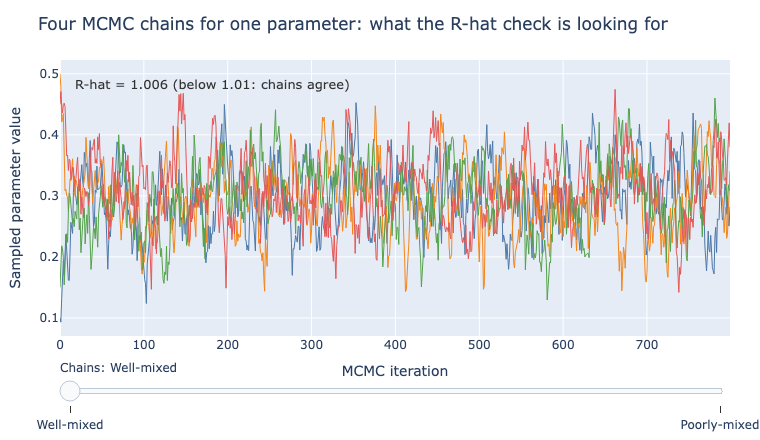

In [18]:
show(fig_rhat_diagnostic())

## Prior predictive checks

Forty draws from the timeout model's priors alone, before any request data, at two prior widths for the payload-size coefficient. The narrower prior (standard deviation 3) keeps most curves gentle; the wider one (standard deviation 10) produces curves that swing from near 0% to near 100% timeout probability within a couple of kilobytes.

In [19]:
def fig_prior_predictive_check() -> go.Figure:
    # A dedicated RNG, decoupled from the module-level RNG other figures share.
    rng = np.random.default_rng(911)
    payload_grid = np.linspace(2, 20, 200)
    payload_centered = payload_grid - 11.0  # matches the centering used in the timeout model
    n_draws = 40
    # sd=3 on the slope still let 29 of 40 draws swing fully from near 0% to near
    # 100% within a couple of kilobytes (confirmed numerically), not the "most
    # curves gentle" contrast the text describes. sd=0.5 is a narrower prior for
    # this slope (the true value the timeout model was built from is 0.35, well
    # within one prior standard deviation), and it keeps the large majority of
    # draws gentle while sd=10 still swings nearly all of them.
    prior_sds = [0.5, 10.0]

    frames = []
    for prior_sd in prior_sds:
        beta0_draws = rng.normal(0, 10, size=n_draws)
        beta1_draws = rng.normal(0, prior_sd, size=n_draws)
        traces = []
        for b0, b1 in zip(beta0_draws, beta1_draws):
            logit_p = b0 + b1 * payload_centered
            p = 1 / (1 + np.exp(-logit_p))
            traces.append(go.Scatter(
                x=payload_grid, y=p, mode="lines",
                line=dict(color="#B279A2", width=1), opacity=0.35,
                showlegend=False, hoverinfo="skip",
            ))
        frames.append(go.Frame(name=f"prior sd={prior_sd}", data=traces))

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Prior predictive check: implied timeout-probability curves before seeing data",
        xaxis_title="Payload size (KB)",
        yaxis_title="Implied timeout probability",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Prior std. dev. on the slope: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 9: robust regression, Normal likelihood vs. Student-t likelihood on
# outlier-contaminated latency data
# ---------------------------------------------------------------------------


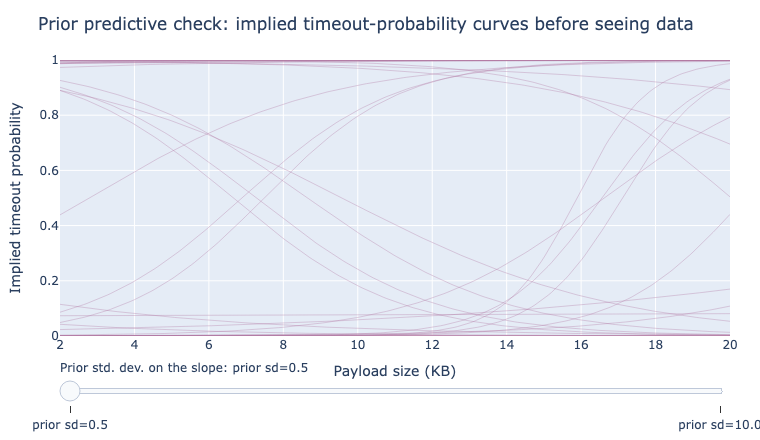

In [20]:
show(fig_prior_predictive_check())

## Posterior predictive checks

Observed latency against data simulated from the fitted model's posterior, under two different noise assumptions. Only the log-normal assumption reproduces the observed right tail.

In [21]:
def fig_posterior_predictive_check() -> go.Figure:
    # A dedicated RNG: this figure's draws no longer need to share the module-level
    # RNG's position with every other figure that still reads from it.
    rng = np.random.default_rng(411)
    payload = rng.uniform(2, 20, size=400)
    noise = rng.lognormal(mean=0, sigma=0.18, size=payload.shape[0]) * 8
    observed = (30 + 9.5 * payload) + noise - 8

    beta0, beta1 = 30.0, 9.5
    # Binning raw latency mixes the noise term in with the much larger spread the
    # payload-size predictor itself contributes (base latency alone spans roughly
    # 49 to 220 ms), which swamps any difference between the two noise
    # assumptions. Subtracting the fitted line isolates the noise term the two
    # models disagree about.
    resid_obs = observed - (beta0 + beta1 * payload)
    resid_sd = float(np.std(resid_obs))

    # One simulated replication understates how much the two noise assumptions
    # differ in the tail; average bin heights over many replications instead,
    # the same averaging thousands of `pm.sample_posterior_predictive` draws
    # would give in the PyMC workflow this figure stands in for.
    n_reps = 200
    bins = np.linspace(-8, 20, 45)
    centers = (bins[:-1] + bins[1:]) / 2
    gauss_hists, ln_hists = [], []
    for _ in range(n_reps):
        resid_gauss = rng.normal(0, resid_sd, size=payload.shape[0])
        resid_ln = rng.lognormal(0, 0.18, size=payload.shape[0]) * 8 - 8
        gauss_hists.append(np.histogram(resid_gauss, bins=bins)[0])
        ln_hists.append(np.histogram(resid_ln, bins=bins)[0])
    hist_gauss = np.mean(gauss_hists, axis=0)
    hist_ln = np.mean(ln_hists, axis=0)
    hist_obs = np.histogram(resid_obs, bins=bins)[0]

    frames = [
        go.Frame(name="Gaussian-noise model", data=[
            go.Bar(x=centers, y=hist_obs, name="Observed", marker_color="#333", opacity=0.55),
            go.Bar(x=centers, y=hist_gauss, name="Posterior predictive mean (200 draws)",
                   marker_color="#E45756", opacity=0.55),
        ]),
        go.Frame(name="Log-normal-noise model", data=[
            go.Bar(x=centers, y=hist_obs, name="Observed", marker_color="#333", opacity=0.55),
            go.Bar(x=centers, y=hist_ln, name="Posterior predictive mean (200 draws)",
                   marker_color="#54A24B", opacity=0.55),
        ]),
    ]

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        barmode="overlay",
        title="Posterior predictive check: does the fitted model's noise assumption fit?",
        xaxis_title="Residual: observed latency minus the fitted line (ms)",
        yaxis_title="Requests",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Noise model: "},
            "steps": [
                # redraw:False here (unlike the other sliders in this chapter): both frames
                # keep the same two Bar traces and only their y-values and marker color
                # change, so a full relayout is not needed, and skipping it keeps the
                # overlay-mode redraw from lagging behind the slider's own label on a
                # bar chart this wide (400 requests binned into 59 bars per trace).
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": False}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 8: prior predictive check, timeout curves implied by the prior alone
# ---------------------------------------------------------------------------


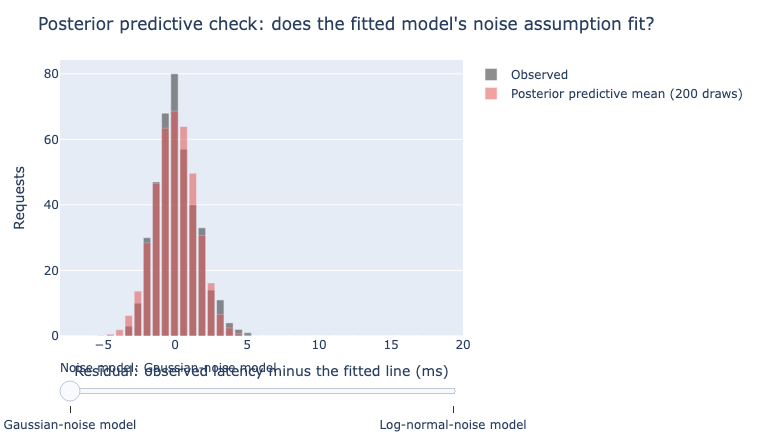

In [22]:
show(fig_posterior_predictive_check())

## Robust regression: when a handful of points sway the whole fit

Same 60 requests, two likelihoods: the Normal-likelihood fit tracks the six retry-storm requests it should ignore; the Student-t-likelihood fit does not.

In [23]:
def fig_robust_regression() -> go.Figure:
    rng = np.random.default_rng(202)
    n = 60
    payload = rng.uniform(2, 20, size=n)
    base = 30 + 9.5 * payload
    noise = rng.lognormal(mean=0, sigma=0.18, size=n) * 8
    latency = base + noise - 8

    # A retry-storm window: a handful of requests each picked up an extra 150-300 ms from
    # an upstream timeout-and-retry, unrelated to their own payload size.
    contam_idx = rng.choice(n, size=6, replace=False)
    spike = rng.uniform(150, 300, size=6)
    latency_contaminated = latency.copy()
    latency_contaminated[contam_idx] = latency_contaminated[contam_idx] + spike

    x, y = payload, latency_contaminated
    x_c = x - x.mean()
    s_xx = float(np.sum(x_c**2))
    beta1_normal = float(np.sum(x_c * (y - y.mean())) / s_xx)
    beta0_normal = float(y.mean() - beta1_normal * x.mean())

    def neg_log_lik_t(params, nu):
        b0, b1, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = b0 + b1 * x
        return -np.sum(stats.t.logpdf(y, df=nu, loc=mu, scale=sigma))

    nu_fixed = 4.0
    resid0 = y - (beta0_normal + beta1_normal * x)
    sigma0 = float(np.std(resid0))
    fit = minimize(
        neg_log_lik_t, x0=[beta0_normal, beta1_normal, np.log(sigma0)], args=(nu_fixed,),
        method="Nelder-Mead", options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 5000},
    )
    beta0_t, beta1_t, _ = fit.x

    x_line = np.linspace(2, 20, 100)
    is_clean = np.ones(n, dtype=bool)
    is_clean[contam_idx] = False

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=x[is_clean], y=y[is_clean], mode="markers", name="Ordinary request",
        marker=dict(color="#4C78A8", size=7, opacity=0.75),
    ))
    fig.add_trace(go.Scatter(
        x=x[~is_clean], y=y[~is_clean], mode="markers", name="Retry-storm request",
        marker=dict(color="#E45756", size=11, symbol="x"),
    ))
    fig.add_trace(go.Scatter(
        x=x_line, y=beta0_normal + beta1_normal * x_line, mode="lines",
        name=f"Normal likelihood (slope {beta1_normal:.2f})",
        line=dict(color="#F58518", width=3, dash="dash"),
    ))
    fig.add_trace(go.Scatter(
        x=x_line, y=beta0_t + beta1_t * x_line, mode="lines",
        name=f"Student-t likelihood (slope {beta1_t:.2f})",
        line=dict(color="#54A24B", width=3),
    ))
    fig.update_layout(
        title="Same 60 requests, two likelihoods: only one fit ignores the retry storm",
        xaxis_title="Payload size (KB)",
        yaxis_title="Latency (ms)",
        legend=dict(x=0.02, y=0.98),
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


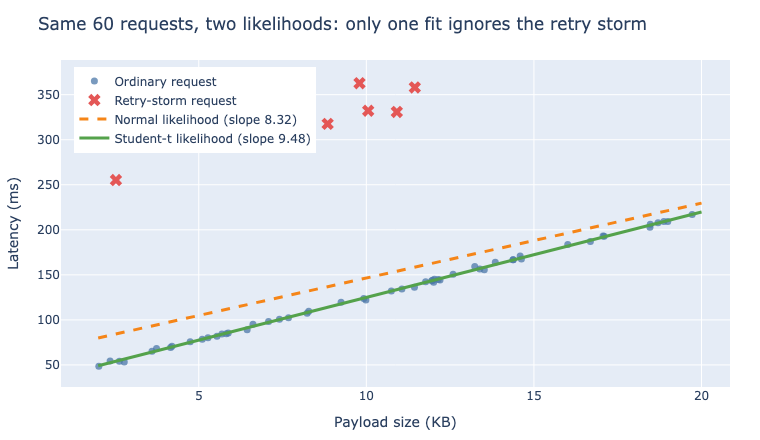

In [24]:
show(fig_robust_regression())

## Hierarchical regression: letting every service borrow strength from the rest

No pooling, complete pooling, and partial pooling for five backend services' payload-size slopes. Partial pooling shrinks fraud-service's noisy four-request estimate hardest, since it has the least data to stand on.

In [25]:
def fig_hierarchical_regression() -> go.Figure:
    rng = np.random.default_rng(505)
    services = ["cart-service", "pricing-service", "inventory-service",
                "shipping-service", "fraud-service"]
    n_per = [140, 110, 85, 50, 4]  # fraud-service just shipped, barely any logged requests
    true_slope = [9.7, 9.3, 9.6, 9.1, 9.5]
    sigma_resid = 10.0

    no_pool_slope, no_pool_se, all_x, all_y = [], [], [], []
    for n_i, b1 in zip(n_per, true_slope):
        x_i = rng.uniform(2, 20, size=n_i)
        y_i = 30 + b1 * x_i + rng.normal(0, sigma_resid, size=n_i)
        x_ic = x_i - x_i.mean()
        sxx_i = float(np.sum(x_ic**2))
        b1_hat = float(np.sum(x_ic * (y_i - y_i.mean())) / sxx_i)
        resid_i = y_i - (y_i.mean() + b1_hat * x_ic)
        dof = max(n_i - 2, 1)
        sigma_hat_i = np.sqrt(np.sum(resid_i**2) / dof)
        no_pool_slope.append(b1_hat)
        no_pool_se.append(sigma_hat_i / np.sqrt(sxx_i))
        all_x.append(x_i)
        all_y.append(y_i)

    no_pool_slope = np.array(no_pool_slope)
    no_pool_se = np.array(no_pool_se)

    x_all, y_all = np.concatenate(all_x), np.concatenate(all_y)
    x_all_c = x_all - x_all.mean()
    sxx_all = float(np.sum(x_all_c**2))
    beta1_pooled = float(np.sum(x_all_c * (y_all - y_all.mean())) / sxx_all)

    # Partial pooling: the same posterior-precision formula from the top of this chapter,
    # applied one level up. Each service's own estimate is combined with the population's
    # distribution across services, weighted by how much each one is trusted.
    precision_j = 1.0 / no_pool_se**2
    grand_mean = float(np.average(no_pool_slope, weights=precision_j))
    tau2 = max(float(np.var(no_pool_slope, ddof=1) - np.mean(no_pool_se**2)), 0.01)
    precision_between = 1.0 / tau2
    w_j = precision_j / (precision_j + precision_between)
    partial_slope = w_j * no_pool_slope + (1 - w_j) * grand_mean
    partial_se = np.sqrt(w_j) * no_pool_se

    y_positions = np.arange(len(services))
    fig = go.Figure()
    offsets = {"No pooling": (-0.22, "#E45756", no_pool_slope, no_pool_se),
               "Complete pooling": (0.0, "#F58518", np.full(len(services), beta1_pooled),
                                     np.zeros(len(services))),
               "Partial pooling": (0.22, "#54A24B", partial_slope, partial_se)}

    for label, (dy, color, slope, se) in offsets.items():
        fig.add_trace(go.Scatter(
            x=slope, y=y_positions + dy, mode="markers", name=label,
            marker=dict(color=color, size=10),
            error_x=dict(type="data", array=1.96 * se, color=color, thickness=2, width=4),
        ))
    fig.add_vline(x=grand_mean, line=dict(color="#999", width=1.5, dash="dot"))
    fig.update_layout(
        title="No pooling, complete pooling, and partial pooling: five services' slopes",
        xaxis_title="Payload-size coefficient (ms per KB)",
        yaxis=dict(tickmode="array", tickvals=list(y_positions), ticktext=services),
        legend=dict(x=0.02, y=0.02),
        margin=dict(t=60, l=140, r=30, b=50),
        height=480,
    )
    return fig


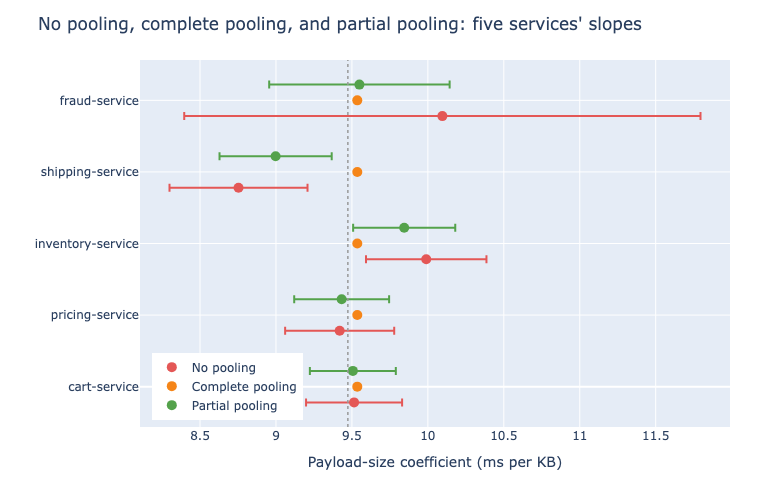

In [26]:
show(fig_hierarchical_regression(), height=480)

## How MCMC explores a posterior, step by step

A from-scratch Metropolis sampler targeting a 25-request posterior this chapter has a closed-form answer for. The step-by-step view shows individual proposals accepted and rejected; the long-run view shows 3,000 post-burn-in samples against the closed-form density.

In [27]:
def fig_metropolis_walkthrough() -> go.Figure:
    rng = np.random.default_rng(303)
    n = 25
    x = rng.uniform(2, 20, size=n)
    base = 30 + 9.5 * x
    noise = rng.lognormal(mean=0, sigma=0.18, size=n) * 8
    y = base + noise - 8

    x_c = x - x.mean()
    s_xx = float(np.sum(x_c**2))
    beta1_hat = float(np.sum(x_c * (y - y.mean())) / s_xx)
    beta0 = float(y.mean())

    prior_mean, prior_var, noise_var = 0.0, 25.0, 2.0**2
    post_var = 1.0 / (1.0 / prior_var + s_xx / noise_var)
    post_mean = post_var * (prior_mean / prior_var + s_xx * beta1_hat / noise_var)
    post_sd = np.sqrt(post_var)

    def log_post(b1):
        mu = beta0 + b1 * x_c
        log_lik = np.sum(stats.norm.logpdf(y, loc=mu, scale=2.0))
        log_prior = stats.norm.logpdf(b1, loc=prior_mean, scale=np.sqrt(prior_var))
        return log_lik + log_prior

    mh_rng = np.random.default_rng(707)
    step, n_iter = 0.08, 4000
    chain = np.empty(n_iter)
    proposed = np.empty(n_iter)
    accepted = np.empty(n_iter, dtype=bool)
    current, current_lp = 0.0, log_post(0.0)
    for i in range(n_iter):
        prop = current + mh_rng.normal(0, step)
        prop_lp = log_post(prop)
        accept = np.log(mh_rng.uniform()) < (prop_lp - current_lp)
        proposed[i], accepted[i] = prop, accept
        if accept:
            current, current_lp = prop, prop_lp
        chain[i] = current

    n_show = 40
    iters = np.arange(n_show)
    accepted_mask = accepted[:n_show]
    x_grid = np.linspace(post_mean - 5 * post_sd, post_mean + 5 * post_sd, 400)
    target_density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
    post_chain = chain[1000:]

    frames = [
        go.Frame(name="Step-by-step mechanics", data=[
            go.Scatter(x=iters, y=chain[:n_show], mode="lines", name="Chain (accepted path)",
                       line=dict(color="#4C78A8", width=2), showlegend=True),
            go.Scatter(x=iters[accepted_mask], y=proposed[:n_show][accepted_mask],
                       mode="markers", name="Proposal accepted", showlegend=True,
                       marker=dict(color="#54A24B", size=9, symbol="triangle-up")),
            # showlegend is pinned explicitly on every trace in both frames (see the
            # "Long-run convergence" frame below): the same merge-not-replace behavior
            # that stales an unset axis range across frames also stales an unset
            # showlegend, so going from the other frame back to this one previously
            # dropped this trace's legend entry.
            go.Scatter(x=iters[~accepted_mask], y=proposed[:n_show][~accepted_mask],
                       mode="markers", name="Proposal rejected", showlegend=True,
                       marker=dict(color="#E45756", size=9, symbol="x")),
        ], layout=go.Layout(
            # Both axes get an explicit setting (a fixed range or autorange=True)
            # in every frame below. Plotly's Plotly.animate() merges each frame's
            # layout onto whatever the page is currently showing; a property left
            # unset in the target frame is not reset, it keeps whatever the prior
            # frame put there. Leaving either axis to its default here is what let
            # the "Long-run convergence" frame inherit this frame's y-axis range
            # of [-0.3, 1.0] and clip its own density curve.
            xaxis=dict(title="Iteration", autorange=True),
            yaxis=dict(title="Coefficient value", range=[-0.3, 1.0], autorange=False),
        )),
        go.Frame(name="Long-run convergence", data=[
            go.Histogram(x=post_chain, histnorm="probability density", name="MH samples",
                         marker_color="#4C78A8", opacity=0.6, nbinsx=40, showlegend=True),
            go.Scatter(x=x_grid, y=target_density, mode="lines", name="Closed-form posterior",
                       line=dict(color="#B279A2", width=3), showlegend=True),
            # A third, empty, legend-hidden trace at the same index the
            # step-by-step frame's "Proposal rejected" markers occupy. Without an
            # explicit replacement here, that trace and its legend entry are left
            # untouched by animate() rather than cleared, since this frame's data
            # only names two traces.
            go.Scatter(x=[], y=[], mode="markers", showlegend=False, hoverinfo="skip"),
        ], layout=go.Layout(
            xaxis=dict(title="Coefficient value",
                       range=[post_mean - 5 * post_sd, post_mean + 5 * post_sd], autorange=False),
            yaxis=dict(title="Density", autorange=True),
        )),
    ]

    fig = go.Figure(data=frames[0].data, layout=frames[0].layout, frames=frames)
    fig.update_layout(
        title="A from-scratch Metropolis sampler, checked against the known closed-form answer",
        legend=dict(x=0.02, y=0.98),
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "View: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 12: why divergences happen, funnel geometry under a centered vs.
# non-centered parameterization  ({#sec-divergences-funnel} in the chapter)
# ---------------------------------------------------------------------------


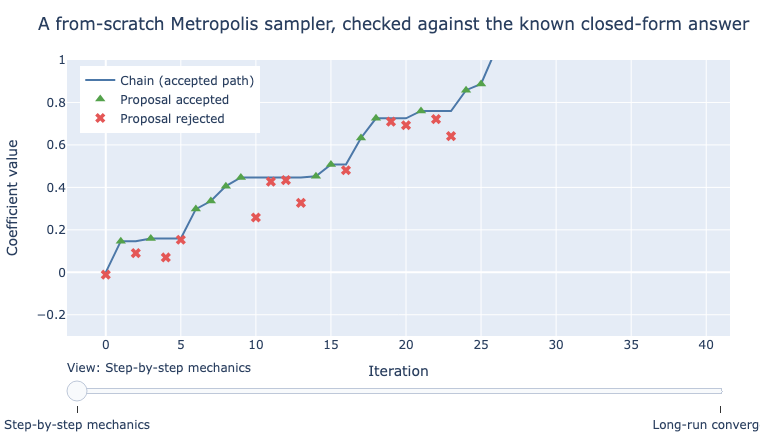

In [28]:
show(fig_metropolis_walkthrough())

## Why divergences happen: the funnel

The same funnel-shaped posterior, sampled two ways. Centered, 16.8% of draws sit where a single step size is more than three times too big for the local geometry. Non-centered, none do.

In [29]:
def fig_divergences_funnel() -> go.Figure:
    rng = np.random.default_rng(909)
    n = 5000

    # Centered: draw the group deviation directly at the population scale exp(log_tau).
    log_tau_c = rng.normal(0, 1.2, size=n)
    effect_c = rng.normal(0, np.exp(log_tau_c))

    # Non-centered: draw a fixed-scale offset first, rescale afterward. Mathematically the
    # same target distribution; a different pair of coordinates for a sampler to move through.
    log_tau_nc = rng.normal(0, 1.2, size=n)
    offset_nc = rng.normal(0, 1.0, size=n)
    effect_nc = offset_nc * np.exp(log_tau_nc)

    # A single global step size (1.0, tuned to the bulk of the distribution near log_tau=0)
    # is badly mismatched to the local scale wherever that step is more than 3x too big for
    # the conditional distribution a sampler would be moving through at that point.
    step_ref, threshold = 1.0, 3.0
    mismatch_c = (step_ref / np.exp(log_tau_c)) > threshold
    mismatch_nc = np.zeros(n, dtype=bool)  # local scale for the offset is always 1: never mismatched

    frames = [
        go.Frame(name="Centered parameterization", data=[
            go.Scatter(x=log_tau_c[~mismatch_c], y=effect_c[~mismatch_c], mode="markers",
                       name="Well-scaled for a fixed step size", marker=dict(color="#4C78A8", size=4, opacity=0.5)),
            go.Scatter(x=log_tau_c[mismatch_c], y=effect_c[mismatch_c], mode="markers",
                       name="Step size badly mismatched (divergence risk)",
                       marker=dict(color="#E45756", size=5, opacity=0.85)),
        ], layout=go.Layout(annotations=[dict(
            x=0.02, y=0.05, xref="paper", yref="paper", showarrow=False, xanchor="left",
            text=f"{100*mismatch_c.mean():.1f}% of draws sit where a global step size is 3x too big",
            font=dict(size=12, color="#333"),
        )])),
        go.Frame(name="Non-centered parameterization", data=[
            go.Scatter(x=log_tau_nc[~mismatch_nc], y=effect_nc[~mismatch_nc], mode="markers",
                       name="Well-scaled for a fixed step size", marker=dict(color="#4C78A8", size=4, opacity=0.5)),
            go.Scatter(x=[], y=[], mode="markers", name="Step size badly mismatched (divergence risk)",
                       marker=dict(color="#E45756", size=5, opacity=0.85)),
        ], layout=go.Layout(annotations=[dict(
            x=0.02, y=0.05, xref="paper", yref="paper", showarrow=False, xanchor="left",
            text="0.0% of draws: the offset's own scale never depends on log_tau",
            font=dict(size=12, color="#333"),
        )])),
    ]

    fig = go.Figure(data=frames[0].data, layout=frames[0].layout, frames=frames)
    fig.update_layout(
        title="Why divergences happen: the funnel's neck, with and without reparameterizing",
        xaxis_title="log(population scale tau)",
        yaxis_title="Group deviation from the population mean",
        yaxis_range=[-15, 15],
        legend=dict(x=0.02, y=0.98),
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Parameterization: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


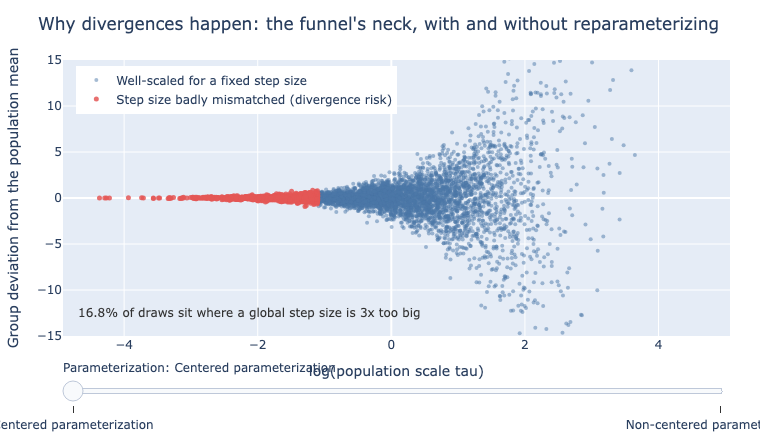

In [30]:
show(fig_divergences_funnel())